# Домашняя работа № 9 · Прогноз временного ряда

**Задача:** спрогнозировать почасовую интенсивность движения на следующую неделю
(168 часов), сравнить несколько моделей с baseline и оценить неопределённость прогноза.

**Уточнение условия.** Название *Metro Interstate Traffic Volume* относится к
агломерации Minneapolis–Saint Paul. В [описании UCI](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)
целевая переменная — количество автомобилей за час на западном направлении I‑94,
а не число пассажиров метро. Наблюдения **почасовые**, поэтому 24 × 7 = 168 точек — неделя.
Все вычисления ниже относятся к этому датасету; единица ошибок — автомобилей/час.

Используются только `date_time`, `traffic_volume`, `holiday`, `temp`.
Все дополнительные признаки получены из этих четырёх столбцов или известного календаря.

**Содержание:** 1. Загрузка и EDA → 2. Очистка и временное разбиение →
3. Выбор истории → 4. Признаки и модели → 5. Валидация →
6. Интервалы → 7. Финальный тест → 8. Прогноз следующей недели → 9. Ответы и выводы.


In [1]:
from pathlib import Path
from time import perf_counter
from importlib.metadata import version
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, Markdown
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf
from threadpoolctl import threadpool_limits

SEED = 42
HORIZON = 24 * 7
TEST_HOURS = 2 * HORIZON
np.random.seed(SEED)

_thread_limit = threadpool_limits(limits=2)
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams.update({'figure.figsize': (13, 4), 'figure.dpi': 110,
                     'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False})
pd.set_option('display.max_columns', 16)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
DATA_PATH = Path('Metro_Interstate_Traffic_Volume.csv')
assert DATA_PATH.exists(), 'Положите CSV в рабочую папку рядом с ноутбуком.'
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

def savefig(name):
    plt.savefig(OUT / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

display(pd.Series({p: version(p) for p in [
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy',
    'scikit-learn', 'statsmodels', 'nbformat', 'nbclient'
]}, name='Версия при выполнении').to_frame())

,Версия при выполнении
numpy,2.1.3
pandas,2.2.3
matplotlib,3.10.0
seaborn,0.13.2
scipy,1.15.3
scikit-learn,1.6.1
statsmodels,0.14.4
nbformat,5.10.4
nbclient,0.10.2


## 1. Загрузка и первичный аудит

Температура задана в кельвинах. Строка `None` в `holiday` означает обычный день,
поэтому отключаем автоматическое распознавание этой строки как пропуска.
Проверяем отдельно полные повторы выбранных столбцов и повторы временной метки

In [3]:
raw = pd.read_csv(DATA_PATH, usecols=['traffic_volume', 'date_time', 'holiday', 'temp'],
                  parse_dates=['date_time'], keep_default_na=False,
                  na_values=[''])
raw = raw[['date_time', 'traffic_volume', 'holiday', 'temp']]
display(raw.head())
display(pd.DataFrame({'Тип': raw.dtypes.astype(str), 'Пропусков': raw.isna().sum(),
                      'Уникальных значений': raw.nunique()}))
display(raw[['traffic_volume', 'temp']].describe())
duplicate_rows = int(raw.duplicated().sum())
duplicate_times = int(raw.duplicated('date_time').sum())
conflicts = raw.groupby('date_time')[['traffic_volume', 'temp', 'holiday']].nunique().gt(1).sum()
display(pd.Series({'Строк в CSV': len(raw), 'Полных повторов (4 столбца)': duplicate_rows,
                   'Повторов времени сверх первой записи': duplicate_times,
                   'Температура 0 K (строк)': int(raw.temp.eq(0).sum()),
                   'Нулевой трафик (строк)': int(raw.traffic_volume.eq(0).sum())}, name='Аудит').to_frame())
display(conflicts.rename('Часов с противоречивыми значениями').to_frame())
display(raw.loc[raw.duplicated('date_time', keep=False)].head(10))

,date_time,traffic_volume,holiday,temp
0,2012-10-02 09:00:00,5545,None,288.28
1,2012-10-02 10:00:00,4516,None,289.36
2,2012-10-02 11:00:00,4767,None,289.58
3,2012-10-02 12:00:00,5026,None,290.13
4,2012-10-02 13:00:00,4918,None,291.14


,Тип,Пропусков,Уникальных значений
date_time,datetime64[ns],0,40575
traffic_volume,int64,0,6704
holiday,object,0,12
temp,float64,0,5843


,traffic_volume,temp
count,"48,204.00","48,204.00"
mean,"3,259.82",281.21
std,"1,986.86",13.34
min,0.00,0.00
25%,"1,193.00",272.16
50%,"3,380.00",282.45
75%,"4,933.00",291.81
max,"7,280.00",310.07


,Аудит
Строк в CSV,48204
Полных повторов (4 столбца),7551
Повторов времени сверх первой записи,7629
Температура 0 K (строк),10
Нулевой трафик (строк),2


,Часов с противоречивыми значениями
traffic_volume,0
temp,78
holiday,0


,date_time,traffic_volume,holiday,temp
178,2012-10-10 07:00:00,6793,None,281.25
179,2012-10-10 07:00:00,6793,None,281.25
180,2012-10-10 08:00:00,6283,None,280.10
181,2012-10-10 08:00:00,6283,None,280.10
182,2012-10-10 09:00:00,5680,None,279.61
183,2012-10-10 09:00:00,5680,None,279.61
269,2012-10-14 09:00:00,2685,None,282.43
270,2012-10-14 09:00:00,2685,None,282.43
271,2012-10-14 09:00:00,2685,None,282.43
272,2012-10-14 10:00:00,3370,None,282.33


## 2. Дубликаты, часовая сетка и пропуски

Сначала удаляем полные повторы четырёх полей. Затем оставляем **одну запись на час**:
трафик у повторов совпадает (это проверяется); для немного различающихся температур
берём медиану уникальных записей. Праздничные метки внутри часа не конфликтуют.
Так мы не суммируем один и тот же трафик несколько раз и не выбираем температуру случайно.

`temp = 0 K` — физически невозможная уличная температура: заменяем её на пропуск.
Настоящие нули трафика сохраняем: без внешних сведений нельзя считать их ошибкой.
Праздник — категориальный признак: его нельзя интерполировать как число.

In [4]:
unique_rows = raw.drop_duplicates().copy()
assert conflicts['traffic_volume'] == 0 and conflicts['holiday'] == 0
unique_rows.loc[unique_rows['temp'] <= 0, 'temp'] = np.nan
hourly = (unique_rows.groupby('date_time', sort=True)
          .agg(traffic_volume=('traffic_volume', 'first'),
               temp=('temp', 'median'), holiday=('holiday', 'first')))
full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq='h', name='date_time')
grid = hourly.reindex(full_index)
grid['observed_target'] = grid.traffic_volume.notna()
grid['observed_temp'] = grid.temp.notna()
grid['holiday'] = grid.holiday.fillna('None')
missing = ~grid.observed_target
run_ids = missing.ne(missing.shift()).cumsum()
gap_table = (pd.DataFrame({'time': grid.index, 'missing': missing.to_numpy(),
                           'run': run_ids.to_numpy()}).query('missing')
             .groupby('run').agg(start=('time', 'min'), end=('time', 'max'), hours=('time', 'size')))
display(gap_table.nlargest(8, 'hours'))
intervals = hourly.index.to_series().diff().value_counts().head(8)
display(intervals.rename('Число интервалов до выравнивания').to_frame())
display(pd.Series({'Уникальных часов': len(hourly), 'Часов в полной сетке': len(grid),
                   'Пропущенных часов': int(missing.sum()),
                   'Доля пропущенных часов, %': missing.mean() * 100,
                   'Максимальный разрыв, часов': int(gap_table.hours.max())}, name='Сетка').to_frame())

,start,end,hours
run,,,
1792,2014-08-08 02:00:00,2015-06-11 19:00:00,7386
1328,2013-10-27 02:00:00,2013-11-06 03:00:00,242
1804,2015-06-14 21:00:00,2015-06-19 17:00:00,117
1566,2014-04-29 09:00:00,2014-05-04 04:00:00,116
2048,2015-10-23 12:00:00,2015-10-27 07:00:00,92
1778,2014-07-27 17:00:00,2014-07-30 08:00:00,64
832,2013-08-31 01:00:00,2013-09-01 22:00:00,46
1812,2015-06-22 19:00:00,2015-06-24 03:00:00,33


,Число интервалов до выравнивания
date_time,
0 days 01:00:00,37986
0 days 02:00:00,2192
0 days 03:00:00,201
0 days 04:00:00,59
0 days 05:00:00,33
0 days 06:00:00,17
0 days 08:00:00,13
0 days 10:00:00,13


,Сетка
Уникальных часов,"40,575.00"
Часов в полной сетке,"52,551.00"
Пропущенных часов,"11,976.00"
"Доля пропущенных часов, %",22.79
"Максимальный разрыв, часов","7,386.00"


### Как заполнить пропуски и не заглянуть в будущее

Используем `pd.date_range(..., freq='h')` и линейную интерполяцию числовых столбцов.
На равномерной сетке `method='linear'` соответствует линейной интерполяции по времени.

**Для каждой даты прогноза сначала отсекаем будущее, затем заполняем историю.**
Внутренние пропуски интерполируем; если пропуск заканчивает доступную историю, используем
последнее доступное значение (`ffill`), поскольку правая точка ещё неизвестна.
Начальные незаполняемые строки удаляем. Фактический трафик в validation/test
**не интерполируем для метрик**: качество считаем только на наблюдавшихся часах.


In [5]:
def clean_available(frame):
    result = frame.copy()
    numeric = ['traffic_volume', 'temp']
    result[numeric] = result[numeric].interpolate(method='linear', limit_area='inside').ffill()
    result = result.dropna(subset=numeric)
    result['temp_c'] = result['temp'] - 273.15
    return result

def history_before(origin, weeks=None):
    # Строго до начала прогнозируемой недели, независимо от заполнения для EDA.
    available = grid.loc[grid.index < origin].copy()
    available = clean_available(available)
    if weeks is not None:
        available = available.iloc[-int(weeks) * HORIZON:]
    assert available.index.max() < origin
    assert not available[['traffic_volume', 'temp']].isna().any().any()
    return available

eda_filled = clean_available(grid)
assert eda_filled.index.is_unique and eda_filled.index.is_monotonic_increasing
assert (eda_filled.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()
assert len(eda_filled) == len(grid)
assert eda_filled[['traffic_volume', 'temp']].notna().all().all()
assert (eda_filled.traffic_volume >= 0).all()
print(f'После обработки: {len(eda_filled):,} часов, шаг 1 час, повторов и числовых пропусков нет.')

# Схема фиксируется до просмотра качества моделей.
test_start = grid.index[-TEST_HOURS]
calibration_start = test_start - pd.Timedelta(weeks=6)
validation_start = calibration_start - pd.Timedelta(weeks=4)
validation_origins = pd.date_range(validation_start, periods=4, freq='7D')
calibration_origins = pd.date_range(calibration_start, periods=6, freq='7D')
test_origins = pd.date_range(test_start, periods=2, freq='7D')
split_table = pd.DataFrame([
    ['История до подбора', grid.index.min(), validation_start - pd.Timedelta(hours=1), 'Обучение / EDA'],
    ['Validation: 4 недели', validation_start, calibration_start - pd.Timedelta(hours=1), 'Выбор окна и модели'],
    ['Calibration: 6 недель', calibration_start, test_start - pd.Timedelta(hours=1), 'Только настройка интервалов'],
    ['Test: 2 недели', test_start, grid.index.max(), 'Финальная оценка'],
], columns=['Часть', 'Начало', 'Конец', 'Назначение'])
display(split_table)
assert len(grid.loc[test_start:]) == 336

После обработки: 52,551 часов, шаг 1 час, повторов и числовых пропусков нет.


,Часть,Начало,Конец,Назначение
0,История до подбора,2012-10-02 09:00:00,2018-07-08 23:00:00,Обучение / EDA
1,Validation: 4 недели,2018-07-09 00:00:00,2018-08-05 23:00:00,Выбор окна и модели
2,Calibration: 6 недель,2018-08-06 00:00:00,2018-09-16 23:00:00,Только настройка интервалов
3,Test: 2 недели,2018-09-17 00:00:00,2018-09-30 23:00:00,Финальная оценка


### Схема оценки недельного прогноза

На каждой дате старта модель получает только прошлое и выдаёт **168 значений сразу**.
После завершения недели фактические данные этой недели становятся доступной историей
для следующего запуска. Последние две недели дают два последовательных недельных
прогноза; это не прогноз на 336 часов из одной точки и не почасовое обновление модели.
Такая проверка соответствует заявленному рабочему горизонту.

Длину окна и модель выбираем на validation. Затем фиксируем их. Calibration не участвует
в выборе модели; тест не участвует ни в подборе параметров, ни в калибровке интервалов.
При последовательных запусках более ранняя validation/calibration/test-неделя может
войти в обучение следующей недели, потому что к этому моменту она уже стала прошлым.

,observed_hours,total_hours,mean_observed_traffic,missing_%
date_time,,,,
2012,2103,2175,"3,226.70",3.31
2013,7294,8760,"3,309.55",16.74
2014,4501,8760,"3,270.14",48.62
2015,3593,8760,"3,258.04",58.98
2016,7838,8784,"3,193.70",10.77
2017,8713,8760,"3,376.59",0.54
2018,4521,4536,"3,303.93",0.33


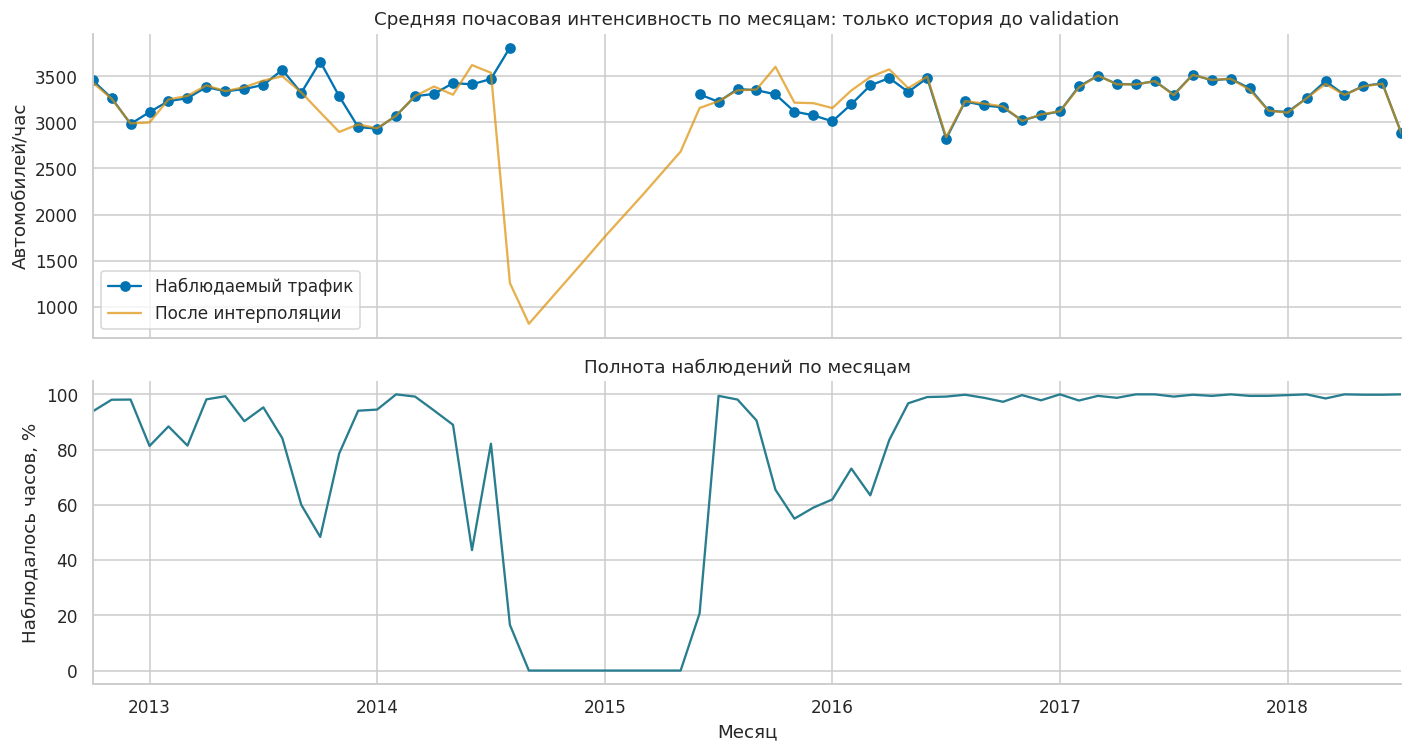

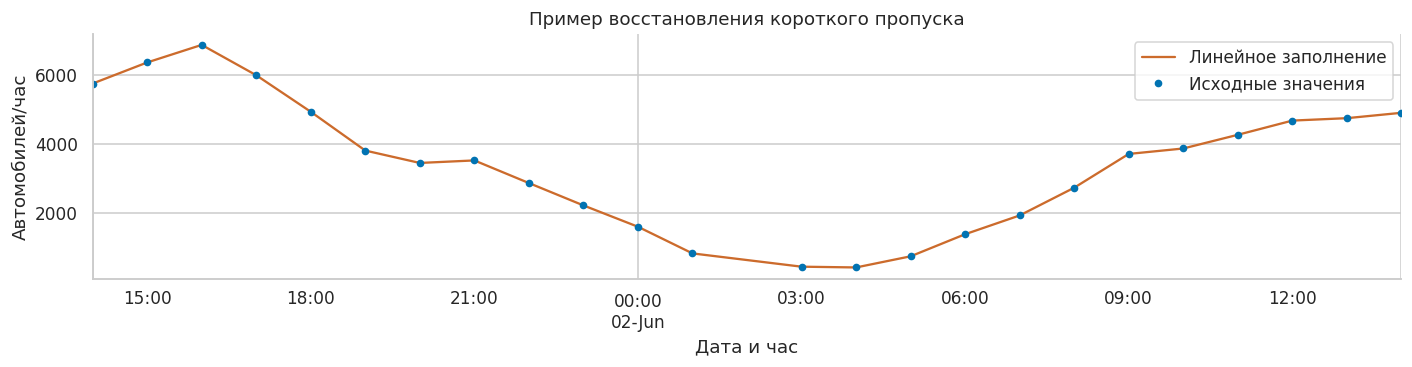

In [6]:
# EDA целевого ряда ограничен данными до первой validation-недели.
eda_raw = grid.loc[grid.index < validation_start].copy()
eda = history_before(validation_start)
year_stats = eda_raw.groupby(eda_raw.index.year).agg(
    observed_hours=('observed_target', 'sum'), total_hours=('observed_target', 'size'),
    mean_observed_traffic=('traffic_volume', 'mean'))
year_stats['missing_%'] = 100 * (1 - year_stats.observed_hours / year_stats.total_hours)
display(year_stats)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
eda_raw.traffic_volume.resample('MS').mean().plot(ax=axes[0], marker='o', label='Наблюдаемый трафик')
eda.traffic_volume.resample('MS').mean().plot(ax=axes[0], alpha=.7, label='После интерполяции')
axes[0].set(title='Средняя почасовая интенсивность по месяцам: только история до validation',
            ylabel='Автомобилей/час', xlabel='')
axes[0].legend()
(100 * eda_raw.observed_target.resample('MS').mean()).plot(ax=axes[1], color='#287d8e')
axes[1].set(title='Полнота наблюдений по месяцам', ylabel='Наблюдалось часов, %', xlabel='Месяц')
fig.tight_layout()
savefig('01_history_and_missing.png')

example_gap = gap_table.loc[(gap_table.start >= '2018-01-01') &
                            (gap_table.end < validation_start)].iloc[-1]
left, right = example_gap.start - pd.Timedelta(hours=12), example_gap.end + pd.Timedelta(hours=12)
fig, ax = plt.subplots(figsize=(13, 3.5))
eda.loc[left:right, 'traffic_volume'].plot(ax=ax, label='Линейное заполнение', color='#cc6b2c')
eda_raw.loc[left:right, 'traffic_volume'].plot(ax=ax, style='o', label='Исходные значения', markersize=4)
ax.set(title='Пример восстановления короткого пропуска', ylabel='Автомобилей/час', xlabel='Дата и час')
ax.legend()
fig.tight_layout()
savefig('02_interpolation.png')

### Суточный и недельный профиль, температура и праздники

Для сезонных профилей берём последние 52 недели до validation и только реальные
значения цели. Это избегает искусственного сглаживания профиля длинными интерполяциями.

,Дат с меткой в CSV
holiday,
Columbus Day,5
Veterans Day,5
Thanksgiving Day,5
Christmas Day,5
New Years Day,5
Washingtons Birthday,5
Memorial Day,5
Independence Day,5
State Fair,5


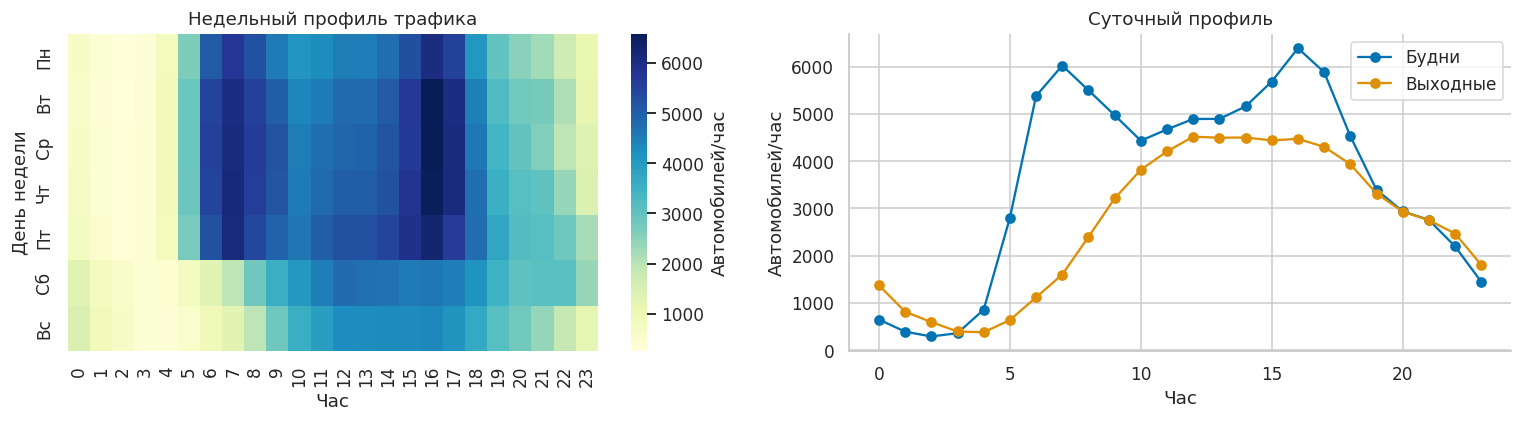

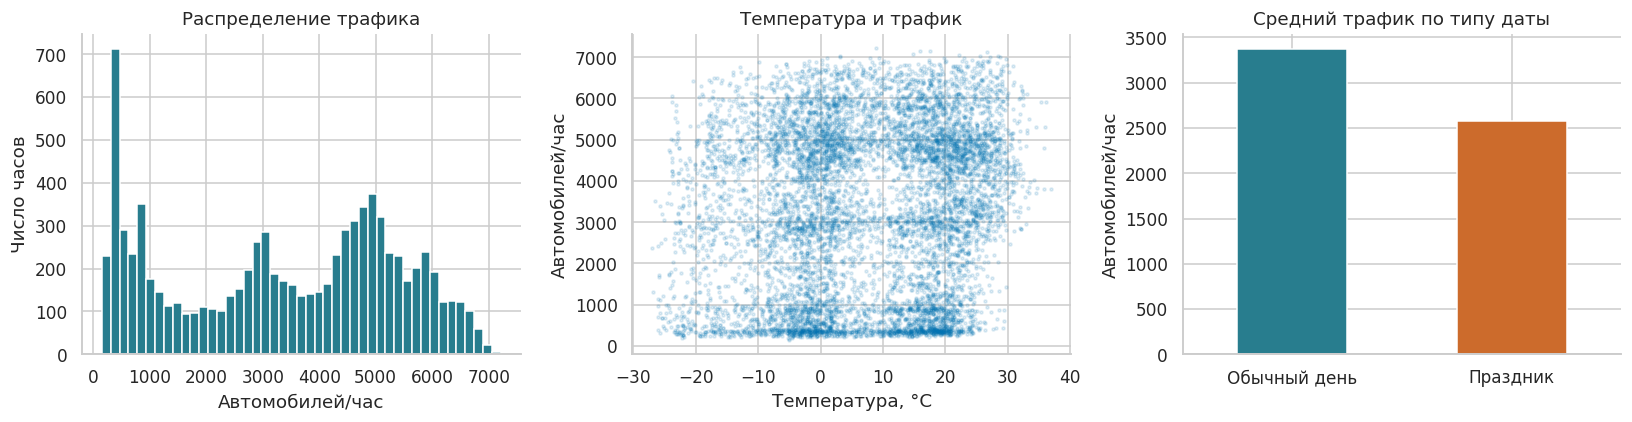

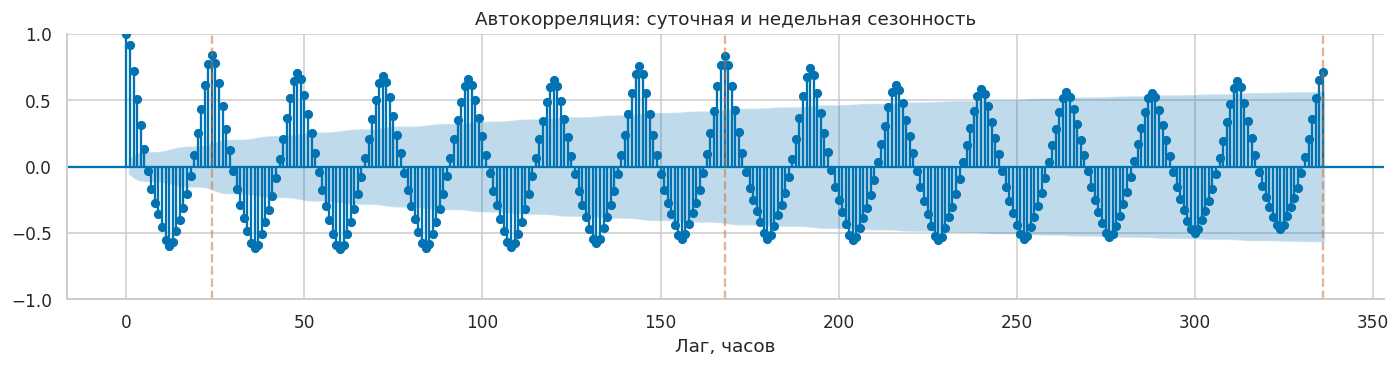

,traffic_volume,temp_c
Корреляция Пирсона,,
traffic_volume,1.00,0.14
temp_c,0.14,1.00


In [8]:
marked = hourly.loc[hourly.holiday.ne('None'), 'holiday']
holiday_by_day = marked.groupby(marked.index.normalize()).first()
federal_days = USFederalHolidayCalendar().holidays(
    start=grid.index.min().normalize(), end=grid.index.max() + pd.Timedelta(days=14))
known_holiday_days = pd.DatetimeIndex(holiday_by_day.index).union(federal_days)

def calendar_features(index):
    index = pd.DatetimeIndex(index)
    x = pd.DataFrame(index=index)
    x['hour'] = index.hour
    x['weekday'] = index.dayofweek
    x['hour_of_week'] = index.dayofweek * 24 + index.hour
    x['month'] = index.month
    x['dayofyear'] = index.dayofyear
    x['is_weekend'] = (index.dayofweek >= 5).astype(int)
    x['is_holiday'] = index.normalize().isin(known_holiday_days).astype(int)
    for name, values, period in [('hour', index.hour, 24),
                                  ('week', index.dayofweek * 24 + index.hour, 168),
                                  ('year', index.dayofyear - 1, 365.25)]:
        x[name + '_sin'] = np.sin(2 * np.pi * values / period)
        x[name + '_cos'] = np.cos(2 * np.pi * values / period)
    return x

recent_eda = eda_raw.tail(52 * HORIZON).copy()
recent_eda = recent_eda.join(calendar_features(recent_eda.index))
recent_eda['temp_c'] = recent_eda.temp - 273.15
display(holiday_by_day.value_counts().rename('Дат с меткой в CSV').to_frame())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
profile = recent_eda.groupby(['weekday', 'hour']).traffic_volume.mean().unstack('hour')
sns.heatmap(profile, ax=axes[0], cmap='YlGnBu', yticklabels=['Пн','Вт','Ср','Чт','Пт','Сб','Вс'],
            cbar_kws={'label': 'Автомобилей/час'})
axes[0].set(title='Недельный профиль трафика', xlabel='Час', ylabel='День недели')
for weekend, group in recent_eda.groupby('is_weekend'):
    group.groupby('hour').traffic_volume.mean().plot(ax=axes[1], marker='o',
        label='Выходные' if weekend else 'Будни')
axes[1].set(title='Суточный профиль', xlabel='Час', ylabel='Автомобилей/час')
axes[1].legend()
fig.tight_layout()
savefig('03_seasonality.png')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
recent_eda.traffic_volume.hist(bins=45, ax=axes[0], color='#287d8e')
axes[0].set(title='Распределение трафика', xlabel='Автомобилей/час', ylabel='Число часов')
axes[1].scatter(recent_eda.temp_c, recent_eda.traffic_volume, s=4, alpha=.12)
axes[1].set(title='Температура и трафик', xlabel='Температура, °C', ylabel='Автомобилей/час')
recent_eda.groupby('is_holiday').traffic_volume.mean().rename(
    index={0:'Обычный день', 1:'Праздник'}).plot.bar(ax=axes[2], rot=0, color=['#287d8e','#cc6b2c'])
axes[2].set(title='Средний трафик по типу даты', xlabel='', ylabel='Автомобилей/час')
fig.tight_layout()
savefig('04_distribution_weather_holiday.png')

fig, ax = plt.subplots(figsize=(13, 3.5))
plot_acf(eda.traffic_volume.tail(8 * HORIZON), lags=2 * HORIZON, fft=True, ax=ax)
for lag in [24, 168, 336]:
    ax.axvline(lag, color='#cc6b2c', alpha=.5, linestyle='--')
ax.set(title='Автокорреляция: суточная и недельная сезонность', xlabel='Лаг, часов')
fig.tight_layout()
savefig('05_acf.png')
display(recent_eda[['traffic_volume', 'temp_c']].corr().rename_axis('Корреляция Пирсона'))

**Выводы EDA.** Повторы времени необходимо убрать; даже при отсутствии NaN в исходном
CSV ряд не является равномерным. Старые годы содержат большие провалы наблюдений,
а в недавней истории полнота существенно выше. Видны повторяющийся суточный профиль
и различия будней и выходных; недельный период 168 часов необходим моделям.
Трафик не обязан быть стационарным по уровню, поэтому длину истории проверяем экспериментально.

Температура сама по себе не объясняет суточный профиль: её связь с трафиком смешана
с временем суток и сезоном. Различие праздничных средних также не является оценкой
причинного эффекта — праздников мало, они приходятся на разные дни недели.
Признаки полезно проверять по качеству **будущего** прогноза, а не только по корреляции.

## 3. Метрики, baseline и выбор объёма истории

Обязательный baseline — средний трафик для каждой пары `(weekday, hour)` в выбранной истории:

Окно выбираем среди **8, 13, 26 и 52 недель** по среднему недельному MAE на четырёх
validation-неделях. Все варианты исключают длительный разрыв 2014–2015 годов.
Длину окна затем фиксируем одинаковой для сравниваемых моделей: это экономный двухэтапный
подбор, а не полный поиск лучшей пары «модель × окно».

Основная метрика — **MAE**, понятная в автомобилях/час. **RMSE** сильнее штрафует крупные
ошибки. **WAPE** = сумма абсолютных ошибок / сумма фактического трафика, в процентах.
MAPE не используем: при нулевом и малом ночном трафике она неустойчива.
Дополнительно **MASE(168)** нормирует MAE на среднюю ошибку недельного повторения
в обучении; значение меньше 1 означает улучшение относительно этого *обучающего* масштаба,
а не обязательно победу над seasonal naive на тесте.

,MAE,RMSE,MAE_std,WAPE_percent
weeks,,,,
13,152.06,214.79,2.31,4.52
8,153.79,227.23,9.22,4.57
52,157.57,218.96,11.70,4.69
26,172.56,235.56,6.16,5.13


**Выбрано окно 13 недель** по минимальному MAE на validation. Ни одна последующая тестовая ошибка не используется для изменения этого окна.

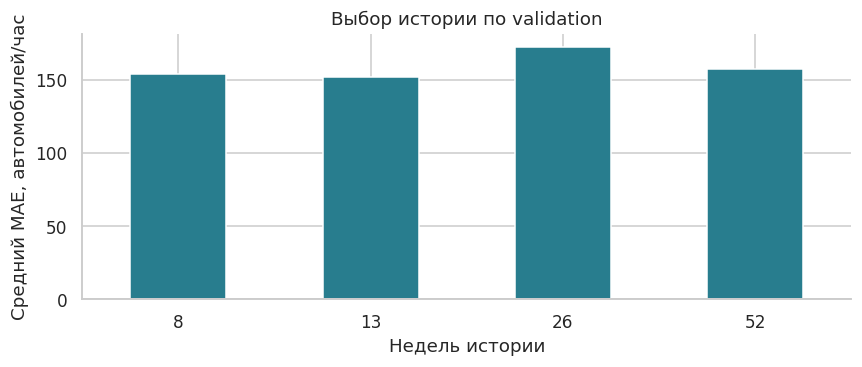

In [10]:
def baseline_predict(history, index):
    train = history.assign(weekday=history.index.dayofweek, hour=history.index.hour)
    means = train.groupby(['weekday', 'hour'])['traffic_volume'].mean()
    keys = pd.MultiIndex.from_arrays([index.dayofweek, index.hour], names=['weekday', 'hour'])
    prediction = means.reindex(keys).to_numpy()
    assert np.isfinite(prediction).all()
    return prediction

def metric_values(actual, prediction, scale=None):
    actual, prediction = np.asarray(actual, float), np.asarray(prediction, float)
    keep = np.isfinite(actual)
    assert keep.any() and np.isfinite(prediction).all()
    actual, prediction = actual[keep], prediction[keep]
    mae = mean_absolute_error(actual, prediction)
    return {'MAE': mae, 'RMSE': np.sqrt(mean_squared_error(actual, prediction)),
            'WAPE_%': 100 * np.abs(actual - prediction).sum() / np.abs(actual).sum(),
            'MASE_168': mae / scale if scale is not None and scale > 0 else np.nan,
            'n_observed': int(len(actual))}

window_records = []
for weeks in [8, 13, 26, 52]:
    for origin in validation_origins:
        hist = history_before(origin, weeks)
        idx = pd.date_range(origin, periods=HORIZON, freq='h')
        values = metric_values(grid.loc[idx, 'traffic_volume'], baseline_predict(hist, idx))
        window_records.append({'weeks': weeks, 'origin': origin, **values})
window_details = pd.DataFrame(window_records)
window_scores = window_details.groupby('weeks').agg(MAE=('MAE','mean'), RMSE=('RMSE','mean'),
    MAE_std=('MAE','std'), WAPE_percent=('WAPE_%','mean')).sort_values('MAE')
BEST_WEEKS = int(window_scores.index[0])
display(window_scores)
display(Markdown(f'**Выбрано окно {BEST_WEEKS} недель** по минимальному MAE на validation. '
                 'Ни одна последующая тестовая ошибка не используется для изменения этого окна.'))
window_scores.to_csv(OUT / 'history_window_validation.csv', encoding='utf-8-sig')
fig, ax = plt.subplots(figsize=(8, 3.5))
window_scores.sort_index().MAE.plot.bar(ax=ax, rot=0, color='#287d8e')
ax.set(title='Выбор истории по validation', xlabel='Недель истории', ylabel='Средний MAE, автомобилей/час')
fig.tight_layout()
savefig('06_history_selection.png')

## 4. Дополнительные признаки и модели

Из индекса создаём час, день недели, номер часа недели, месяц, день года, выходной,
праздник, синусы и косинусы суточного, недельного и годового циклов. Циклическое
кодирование сохраняет близость 23:00 и 00:00.

Для регрессий добавляем трафик **168, 336, 504 и 672 часа назад**, среднее этих четырёх
недельных лагов и среднее за 24 часа, заканчивающиеся на лаге 168. Все лаги не меньше
горизонта: в начале недели значения доступны сразу для всех 168 прогнозируемых часов.
Лаги 1 и 24 часа для такого прямого недельного прогноза без рекурсии использовать нельзя.
Строки обучения с интерполированной целью исключаем; заполненную историю разрешаем
использовать в лагах, а для их исходной наблюдаемости добавляем индикаторы.

### Отдельный прогноз температуры

Будущие фактические `temp` не подставляем в регрессию. Оцениваем SARIMA
`(1,0,1) × (0,1,0,24)` на последних 8 неделях доступной температуры. Суточное
дифференцирование выполняется до оценивания (`simple_differencing=True`), после чего
прогноз возвращается в исходную шкалу рекурсией
\(\hat T_t=\widehat{\Delta_{24}T_t}+T_{t-24}\).
Порядок модели задан заранее; температуру проверяем на validation отдельно.

Температура в обучении регрессии — историческая фактическая, а на горизонте — прогнозная.
Это создаёт различие качества признака между обучением и применением; проверка на
validation с прогнозной температурой позволяет увидеть, полезен ли такой вариант.

In [11]:
LAGS = [168, 336, 504, 672]

def design_matrix(frame):
    x = calendar_features(frame.index)
    for lag in LAGS:
        x[f'lag_{lag}'] = frame.traffic_volume.shift(lag)
        x[f'lag_{lag}_observed'] = frame.observed_target.astype(float).shift(lag)
    lag_cols = [f'lag_{lag}' for lag in LAGS]
    x['weekly_mean_4'] = x[lag_cols].mean(axis=1)
    x['lag168_rolling24'] = frame.traffic_volume.shift(168).rolling(24).mean()
    x['temp_c'] = frame.temp_c
    return x

def restore_seasonal_difference(predicted_diff, history, period):
    values = list(np.asarray(history, float))
    for delta in np.asarray(predicted_diff, float):
        values.append(float(delta + values[-period]))
    return np.asarray(values[-len(predicted_diff):])

fit_diagnostics = []

def fit_sarima(values, period, label, origin):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fit = SARIMAX(np.asarray(values, float), order=(1,0,1),
                      seasonal_order=(0,1,0,period), trend='n',
                      simple_differencing=True,
                      enforce_stationarity=True, enforce_invertibility=True).fit(disp=False, maxiter=150)
    fit_diagnostics.append({'origin': origin, 'model': label,
                            'converged': bool(fit.mle_retvals.get('converged', False)),
                            'warnings': ' | '.join(sorted({str(w.message) for w in caught}))})
    # Не скрываем неуспешную оптимизацию и не подменяем модель незаметно baseline.
    if not fit.mle_retvals.get('converged', False):
        raise RuntimeError(f'{label}: оптимизация не сошлась, проверьте diagnostics.')
    return fit

def forecast_temperature(history, index):
    temperature = history.temp_c.tail(8 * HORIZON)
    fitted = fit_sarima(temperature, 24, 'Temperature SARIMA', index[0])
    diff = np.asarray(fitted.forecast(len(index)))
    return restore_seasonal_difference(diff, temperature, 24)

def make_ml_data(history, index, temperature_prediction):
    future = pd.DataFrame(index=index, columns=history.columns)
    future['traffic_volume'] = np.nan
    future['temp_c'] = temperature_prediction
    future['observed_target'] = False
    # Числовой ряд с пустой будущей целью: чтение неизвестных y приведёт к NaN.
    joined = pd.DataFrame(index=history.index.append(index))
    joined['traffic_volume'] = pd.concat([history.traffic_volume, future.traffic_volume]).astype(float)
    joined['temp_c'] = pd.concat([history.temp_c, future.temp_c]).astype(float)
    joined['observed_target'] = pd.concat([history.observed_target, future.observed_target]).astype(bool)
    features = design_matrix(joined)
    train_x = features.loc[history.index]
    valid = history.observed_target & train_x.notna().all(axis=1)
    train_x = train_x.loc[valid]
    train_y = history.loc[valid, 'traffic_volume']
    future_x = features.loc[index]
    assert future_x.notna().all().all(), 'Недоступный лаг на горизонте!'
    assert train_x.index.max() < index.min()
    assert index.max() - pd.Timedelta(hours=min(LAGS)) <= history.index.max()
    return train_x, train_y, future_x

example_history = history_before(validation_start, BEST_WEEKS)
# Для иллюстрации матрицы используем исторические строки, не оцениваем модель на примере.
display(design_matrix(example_history).dropna().head())

,hour,weekday,hour_of_week,month,dayofyear,is_weekend,is_holiday,hour_sin,...,lag_336_observed,lag_504,lag_504_observed,lag_672,lag_672_observed,weekly_mean_4,lag168_rolling24,temp_c
date_time,,,,,,,,,,,,,,,,,
2018-05-07 00:00:00,0,0,0,5,127,0,0,0.00,...,1.00,407.00,1.00,427.00,1.00,497.25,"2,606.38",16.47
2018-05-07 01:00:00,1,0,1,5,127,0,0,0.26,...,1.00,272.00,1.00,315.00,1.00,315.75,"2,585.79",16.01
2018-05-07 02:00:00,2,0,2,5,127,0,0,0.50,...,1.00,247.00,1.00,251.00,1.00,258.00,"2,572.21",15.40
2018-05-07 03:00:00,3,0,3,5,127,0,0,0.71,...,1.00,357.00,1.00,339.00,1.00,356.00,"2,572.54",14.87
2018-05-07 04:00:00,4,0,4,5,127,0,0,0.87,...,1.00,779.00,1.00,869.00,1.00,859.75,"2,598.00",14.27


### Сравниваемые подходы

| Модель | Что учитывает |
|---|---|
| Baseline | Среднее по дню недели и часу |
| Seasonal naive | Повторение последней недели: \(\hat y_t=y_{t-168}\) |
| Holt–Winters | Адаптивное экспоненциальное сглаживание, аддитивная сезонность 168, без тренда |
| SARIMA | `(1,0,1) × (0,1,0,168)`: недельная разность и краткосрочная ARMA-динамика |
| Ridge | Линейная регрессия с регуляризацией, календарём и недельными лагами |
| HistGB | Градиентный бустинг по деревьям, календарь и недельные лаги |
| HistGB + temp | Те же признаки плюс отдельно спрогнозированная температура |
| Ensemble | Простое среднее Baseline и HistGB; вес 1/2 задан заранее |

У Ridge календарные категории кодируются one-hot, численные признаки масштабируются
**внутри обучающей выборки**. У бустинга фиксированы 220 итераций, глубина ограничена
15 листьями; случайная early-stopping-валидация отключена. Ridge и бустинг предсказывают
поправку к среднему четырёх недельных лагов, чтобы сначала использовать сильный сезонный ориентир.
Отрицательные прогнозы обрезаются на нуле для всех моделей одинаково.

У SARIMA недельная сезонность задана явно. При `simple_differencing=True` прогноз
выходит в шкале разностей, поэтому восстанавливаем исходный трафик, прибавляя значение
предыдущей недели ([документация statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)).
Такой порядок позволяет избежать дорогой модели с сотнями скрытых состояний.
Это один осмысленный вариант SARIMA, а не исчерпывающий поиск порядков.

In [12]:
MODEL_NAMES = ['Baseline', 'Seasonal naive', 'Holt-Winters', 'SARIMA',
               'Ridge', 'HistGB', 'HistGB + temp', 'Ensemble']
MODEL_PARAMS = dict(max_iter=220, learning_rate=0.05, max_leaf_nodes=15,
                    min_samples_leaf=25, l2_regularization=10.0,
                    early_stopping=False, random_state=SEED)

def predict_models(history, index, names=None):
    names = list(MODEL_NAMES if names is None else names)
    needed = set(names)
    if 'Ensemble' in needed:
        needed.update(['Baseline', 'HistGB'])
    assert len(index) == HORIZON
    assert index.min() == history.index.max() + pd.Timedelta(hours=1)
    pred = {}
    if 'Baseline' in needed:
        pred['Baseline'] = baseline_predict(history, index)
    if 'Seasonal naive' in needed:
        pred['Seasonal naive'] = history.traffic_volume.iloc[-HORIZON:].to_numpy()
    if 'Holt-Winters' in needed:
        # Масштаб в тысячах машин стабилизирует численную оптимизацию.
        fit = ExponentialSmoothing(history.traffic_volume.to_numpy() / 1000, trend=None,
            seasonal='add', seasonal_periods=HORIZON, initialization_method='estimated').fit(
                optimized=True, use_brute=False, minimize_kwargs={'options': {'maxiter': 500}})
        fit_diagnostics.append({'origin': index[0], 'model': 'Holt-Winters',
            'converged': bool(fit.mle_retvals.success), 'warnings': str(fit.mle_retvals.message)})
        if not fit.mle_retvals.success:
            raise RuntimeError('Holt-Winters: оптимизация не сошлась.')
        pred['Holt-Winters'] = 1000 * np.asarray(fit.forecast(HORIZON))
    if 'SARIMA' in needed:
        fit = fit_sarima(history.traffic_volume, HORIZON, 'SARIMA', index[0])
        pred['SARIMA'] = restore_seasonal_difference(
            fit.forecast(HORIZON), history.traffic_volume, HORIZON)
    temperature_pred = None
    ml_needed = needed.intersection(['Ridge', 'HistGB', 'HistGB + temp'])
    if ml_needed:
        temperature_pred = (forecast_temperature(history, index) if 'HistGB + temp' in needed
                            else np.zeros(len(index)))
        train_x, train_y, future_x = make_ml_data(history, index, temperature_pred)
        anchor_train, anchor_future = train_x.weekly_mean_4, future_x.weekly_mean_4
        residual_target = train_y - anchor_train
        for name in sorted(ml_needed):
            columns = list(train_x.columns)
            if name != 'HistGB + temp':
                columns.remove('temp_c')
            if name == 'Ridge':
                categorical = ['hour', 'weekday', 'hour_of_week', 'month']
                numerical = [c for c in columns if c not in categorical]
                preprocess = ColumnTransformer([
                    ('calendar', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
                    ('numeric', StandardScaler(), numerical)])
                model = make_pipeline(preprocess, Ridge(alpha=100.0))
            else:
                model = HistGradientBoostingRegressor(**MODEL_PARAMS)
            model.fit(train_x[columns], residual_target)
            pred[name] = anchor_future.to_numpy() + model.predict(future_x[columns])
    if 'Ensemble' in needed:
        pred['Ensemble'] = .5 * pred['Baseline'] + .5 * pred['HistGB']
    result = pd.DataFrame({name: np.maximum(0, pred[name]) for name in names}, index=index)
    assert np.isfinite(result.to_numpy()).all()
    return result, temperature_pred

def evaluate_origins(origins, names=None, label=''):
    rows, forecasts, temperature_rows = [], [], []
    for origin in origins:
        started = perf_counter()
        history = history_before(origin, BEST_WEEKS)
        idx = pd.date_range(origin, periods=HORIZON, freq='h', name='date_time')
        predicted, temperature_pred = predict_models(history, idx, names)
        truth = grid.loc[idx, 'traffic_volume']
        # Масштаб MASE только на парах реальных исторических наблюдений.
        observed_history = history.traffic_volume.where(history.observed_target)
        scale = observed_history.diff(HORIZON).abs().mean()
        for name in predicted:
            rows.append({'origin': origin, 'model': name,
                          **metric_values(truth, predicted[name], scale)})
            forecasts.append(pd.DataFrame({'date_time': idx, 'origin': origin,
                'horizon': np.arange(1, HORIZON + 1), 'model': name,
                'actual': truth.to_numpy(), 'prediction': predicted[name].to_numpy()}))
        if temperature_pred is not None and 'HistGB + temp' in predicted:
            true_temp = grid.loc[idx, 'temp'] - 273.15
            temperature_rows.append(pd.DataFrame({'date_time': idx, 'origin': origin,
                'actual_temp_c': true_temp.to_numpy(), 'forecast_temp_c': temperature_pred}))
        print(f'{label}: {origin:%Y-%m-%d} · {len(predicted.columns)} моделей · '
              f'{int(truth.notna().sum())}/168 наблюдений · {perf_counter()-started:.1f} с', flush=True)
    return pd.DataFrame(rows), pd.concat(forecasts, ignore_index=True), (
        pd.concat(temperature_rows, ignore_index=True) if temperature_rows else pd.DataFrame())

## 5. Выбор модели на validation

Каждая модель получает одинаковые даты старта, длину истории и горизонт. Ранжируем по
среднему MAE четырёх недель, дополнительно показываем разброс между неделями.
При равенстве MAE вторичный критерий — RMSE. После этой ячейки победитель фиксируется;
дальнейшие результаты не меняют выбор.

Validation: 2018-07-09 · 8 моделей · 168/168 наблюдений · 9.7 с
Validation: 2018-07-16 · 8 моделей · 168/168 наблюдений · 8.2 с
Validation: 2018-07-23 · 8 моделей · 168/168 наблюдений · 8.4 с
Validation: 2018-07-30 · 8 моделей · 168/168 наблюдений · 8.1 с


,MAE,MAE_std,RMSE,WAPE_percent,MASE_168
model,,,,,
Baseline,152.06,2.31,214.79,4.52,0.52
Ensemble,158.08,29.11,230.37,4.70,0.53
Holt-Winters,181.15,34.34,237.51,5.39,0.62
HistGB,227.47,99.29,331.07,6.76,0.76
Seasonal naive,235.69,175.57,412.10,7.02,0.78
HistGB + temp,239.30,112.92,347.42,7.12,0.80
SARIMA,244.57,190.72,415.56,7.29,0.81
Ridge,267.95,19.39,369.65,7.97,0.91


model,Baseline,Ensemble,HistGB,HistGB + temp,Holt-Winters,Ridge,SARIMA,Seasonal naive
origin,,,,,,,,
2018-07-09,151.21,197.75,360.70,394.21,152.39,275.47,530.41,498.76
2018-07-16,152.87,161.03,243.51,250.11,206.11,264.88,141.31,139.79
2018-07-23,149.37,141.91,167.44,170.77,150.79,242.79,146.43,144.86
2018-07-30,154.79,131.64,138.21,142.11,215.30,288.66,160.14,159.37


**Зафиксирована модель: Baseline.** Средний validation MAE = 152.1 автомобилей/час.

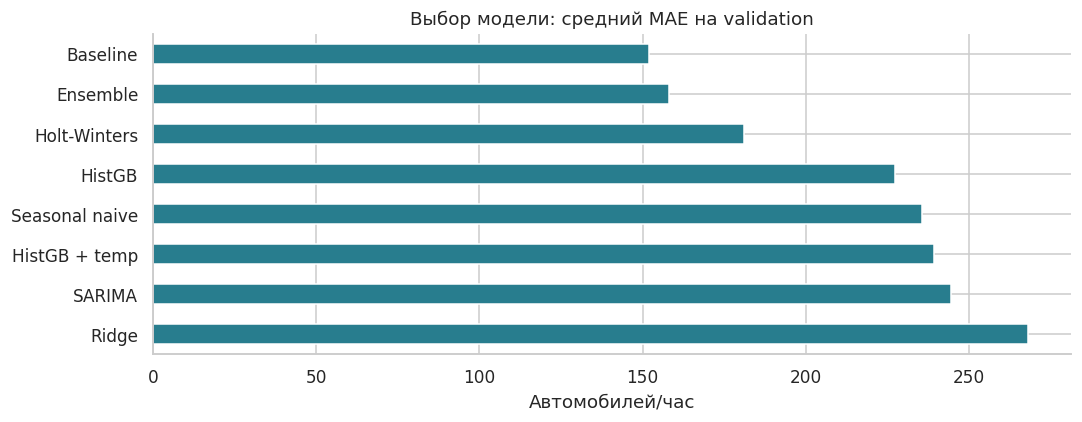

model,Baseline,Ensemble,HistGB,HistGB + temp,Holt-Winters,Ridge,SARIMA,Seasonal naive
origin,,,,,,,,
2018-07-09,151.21,197.75,360.70,394.21,152.39,275.47,530.41,498.76
2018-07-16,152.87,161.03,243.51,250.11,206.11,264.88,141.31,139.79
2018-07-23,149.37,141.91,167.44,170.77,150.79,242.79,146.43,144.86
2018-07-30,154.79,131.64,138.21,142.11,215.30,288.66,160.14,159.37


**Зафиксирована модель: Baseline.** Средний validation MAE = 152.1 автомобилей/час.

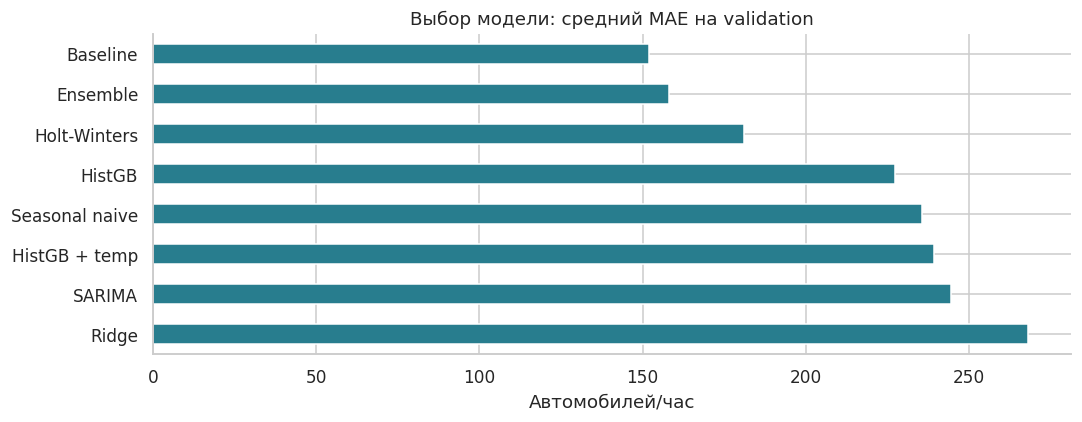

In [13]:
validation_metrics, validation_predictions, validation_temperature = evaluate_origins(
    validation_origins, label='Validation')
validation_summary = validation_metrics.groupby('model').agg(
    MAE=('MAE','mean'), MAE_std=('MAE','std'), RMSE=('RMSE','mean'),
    WAPE_percent=('WAPE_%','mean'), MASE_168=('MASE_168','mean')).sort_values(['MAE','RMSE'])
SELECTED_MODEL = validation_summary.index[0]
display(validation_summary)
display(validation_metrics.pivot(index='origin', columns='model', values='MAE'))
display(Markdown(f'**Зафиксирована модель: {SELECTED_MODEL}.** '
    f'Средний validation MAE = {validation_summary.loc[SELECTED_MODEL, "MAE"]:.1f} автомобилей/час.'))
validation_summary.to_csv(OUT / 'validation_metrics.csv', encoding='utf-8-sig')
fig, ax = plt.subplots(figsize=(10, 4))
validation_summary.MAE.sort_values(ascending=False).plot.barh(ax=ax, color='#287d8e')
ax.set(title='Выбор модели: средний MAE на validation', xlabel='Автомобилей/час', ylabel='')
fig.tight_layout()
savefig('07_validation_comparison.png')

,Проверка погоды
"Temperature MAE, °C",2.76
"Temperature RMSE, °C",3.40
Уменьшение MAE трафика от temp,-11.84


**Температура:** вариант с прогнозной температурой не улучшил validation MAE (разница -11.8). Фактическая будущая погода в признаки не передавалась.

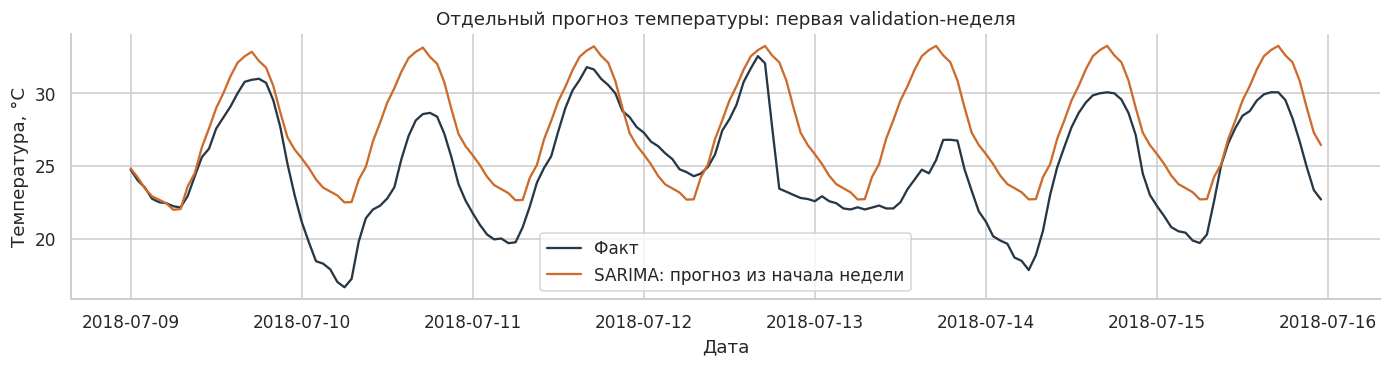

In [14]:
temp_valid = validation_temperature.dropna(subset=['actual_temp_c'])
temp_mae = mean_absolute_error(temp_valid.actual_temp_c, temp_valid.forecast_temp_c)
temp_rmse = np.sqrt(mean_squared_error(temp_valid.actual_temp_c, temp_valid.forecast_temp_c))
temp_gain = validation_summary.loc['HistGB', 'MAE'] - validation_summary.loc['HistGB + temp', 'MAE']
display(pd.Series({'Temperature MAE, °C': temp_mae, 'Temperature RMSE, °C': temp_rmse,
                   'Уменьшение MAE трафика от temp': temp_gain}, name='Проверка погоды').to_frame())
display(Markdown('**Температура:** ' + (
    f'вариант с прогнозной температурой снизил validation MAE на {temp_gain:.1f} автомобилей/час.'
    if temp_gain > 0 else
    f'вариант с прогнозной температурой не улучшил validation MAE (разница {temp_gain:.1f}).') +
    ' Фактическая будущая погода в признаки не передавалась.'))
fig, ax = plt.subplots(figsize=(13, 3.5))
first_temp = validation_temperature.loc[validation_temperature.origin.eq(validation_origins[0])]
ax.plot(first_temp.date_time, first_temp.actual_temp_c, label='Факт', color='#263746')
ax.plot(first_temp.date_time, first_temp.forecast_temp_c, label='SARIMA: прогноз из начала недели', color='#cc6b2c')
ax.set(title='Отдельный прогноз температуры: первая validation-неделя', ylabel='Температура, °C', xlabel='Дата')
ax.legend()
fig.tight_layout()
savefig('08_temperature_forecast.png')

## 6. Прогнозные интервалы: отдельная калибровка до теста

Для будущего наблюдения нужен **прогнозный интервал**, а не доверительный интервал
среднего отклика. Оцениваем абсолютные ошибки зафиксированной модели на шести последующих
calibration-неделях (модель каждый раз переобучается только на прошлом).

Чтобы учитывать разные масштабы дневных и ночных ошибок, делим их на четыре группы:
будний/выходной × день (06–21)/ночь. Внутри группы берём порядковую статистику
\(q_g=e_{(\lceil(n_g+1)\cdot0.95\rceil)}\) и строим
\([\max(0,\hat y_t-q_g),\ \hat y_t+q_g]\).
При недостаточном числе ошибок используем общий квантиль. Праздничные ошибки остаются
в калибровке, но самостоятельной праздничной группы с достаточным числом примеров нет.

Это эмпирическая калибровка по идее split conformal. Ошибки временного ряда зависимы,
модель переобучается, а распределение может меняться: **строгой гарантии 95% покрытия нет**.
95% — номинальный уровень для отдельного часа, не вероятность одновременного покрытия
всей недели. Фактическое покрытие обязательно проверим на независимом тесте.

In [15]:
calibration_metrics, calibration_predictions, _ = evaluate_origins(
    calibration_origins, names=[SELECTED_MODEL], label='Calibration')

def interval_group(index):
    idx = pd.DatetimeIndex(index)
    return np.char.add(np.where(idx.dayofweek < 5, 'Будни', 'Выходные'), np.where(
        (idx.hour >= 6) & (idx.hour < 22), ' / день', ' / ночь'))

def finite_sample_quantile(errors, coverage=.95):
    errors = np.sort(np.asarray(errors, float))
    assert len(errors) >= 20
    rank = min(len(errors), int(np.ceil((len(errors) + 1) * coverage)))
    return errors[rank - 1]

calibration_scored = calibration_predictions.dropna(subset=['actual']).copy()
calibration_scored['abs_error'] = (calibration_scored.actual - calibration_scored.prediction).abs()
calibration_scored['group'] = interval_group(calibration_scored.date_time)
global_q = finite_sample_quantile(calibration_scored.abs_error)
interval_records = []
for group, part in calibration_scored.groupby('group'):
    interval_records.append({'group': group, 'n': len(part),
        'q95': finite_sample_quantile(part.abs_error) if len(part) >= 40 else global_q})
interval_calibration = pd.DataFrame(interval_records).set_index('group')
display(interval_calibration)
interval_calibration.to_csv(OUT / 'interval_calibration.csv', encoding='utf-8-sig')

def add_intervals(frame):
    result = frame.copy()
    groups = pd.Series(interval_group(result.date_time), index=result.index)
    radius = groups.map(interval_calibration.q95).fillna(global_q).to_numpy()
    result['lower_95'] = np.maximum(0, result.prediction.to_numpy() - radius)
    result['upper_95'] = result.prediction.to_numpy() + radius
    assert (result.lower_95 <= result.prediction).all()
    assert (result.prediction <= result.upper_95).all()
    return result

Calibration: 2018-08-06 · 1 моделей · 165/168 наблюдений · 0.1 с
Calibration: 2018-08-13 · 1 моделей · 168/168 наблюдений · 0.1 с
Calibration: 2018-08-20 · 1 моделей · 167/168 наблюдений · 0.1 с
Calibration: 2018-08-27 · 1 моделей · 168/168 наблюдений · 0.1 с
Calibration: 2018-09-03 · 1 моделей · 168/168 наблюдений · 0.1 с
Calibration: 2018-09-10 · 1 моделей · 168/168 наблюдений · 0.1 с


,n,q95
group,,
Будни / день,477,714.46
Будни / ночь,239,463.00
Выходные / день,192,624.62
Выходные / ночь,96,480.62


Calibration: 2018-08-20 · 1 моделей · 167/168 наблюдений · 0.0 с


Calibration: 2018-08-27 · 1 моделей · 168/168 наблюдений · 0.0 с


Calibration: 2018-09-03 · 1 моделей · 168/168 наблюдений · 0.0 с


Calibration: 2018-09-10 · 1 моделей · 168/168 наблюдений · 0.0 с


,n,q95
group,,
Будни / день,477,714.46
Будни / ночь,239,463.00
Выходные / день,192,624.62
Выходные / ночь,96,480.62


## 7. Финальная проверка на последних двух неделях

Теперь один раз оцениваем **все модели** на отложенных 336 часах по схеме 2 × 168.
Для сводной таблицы метрики считаем по объединённым часовым прогнозам;
MASE усредняем по двум недельным запускам. Выбранная ранее модель остаётся итоговой,
даже если другая модель случайно окажется первой на коротком тесте.

Test: 2018-09-17 · 8 моделей · 168/168 наблюдений · 7.7 с
Test: 2018-09-24 · 8 моделей · 168/168 наблюдений · 8.4 с


,MAE,RMSE,WAPE_%,MASE_168,n_observed,MAE_improvement_vs_baseline_%,selected_on_validation
model,,,,,,,
Ensemble,190.09,291.81,5.63,0.72,336,4.43,False
Baseline,198.91,290.17,5.90,0.75,336,0.00,True
Seasonal naive,205.86,333.91,6.10,0.77,336,-3.49,False
SARIMA,207.44,334.20,6.15,0.78,336,-4.29,False
HistGB,213.79,332.06,6.34,0.80,336,-7.48,False
HistGB + temp,223.16,331.28,6.62,0.84,336,-12.19,False
Ridge,224.55,349.71,6.66,0.85,336,-12.89,False
Holt-Winters,518.38,594.79,15.37,1.95,336,-160.61,False


model,Baseline,Ensemble,HistGB,HistGB + temp,Holt-Winters,Ridge,SARIMA,Seasonal naive
origin,,,,,,,,
2018-09-17,213.48,197.90,219.85,224.41,447.05,237.25,211.09,209.85
2018-09-24,184.34,182.29,207.72,221.92,589.70,211.85,203.80,201.88


,Интервалы на тесте
"Номинальное покрытие, %",95.00
"Покрытие на тесте, %",95.54
"Средняя ширина, автомобилей/час","1,220.50"
Наблюдавшихся часов из 336,336.00


,n,coverage
group,,
Будни / день,160,0.99
Будни / ночь,80,0.95
Выходные / день,64,0.95
Выходные / ночь,32,0.81


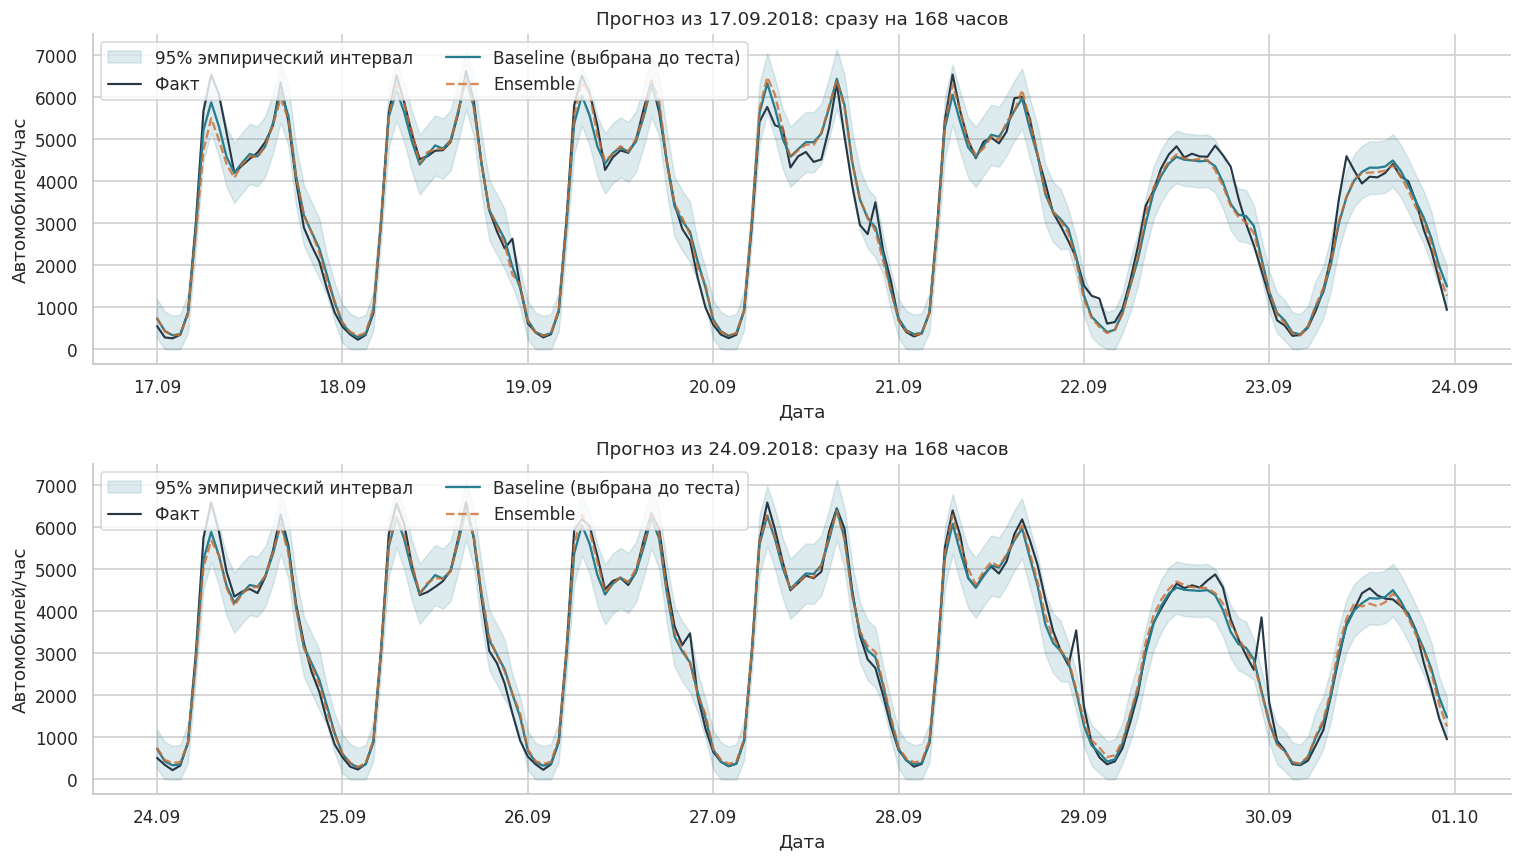

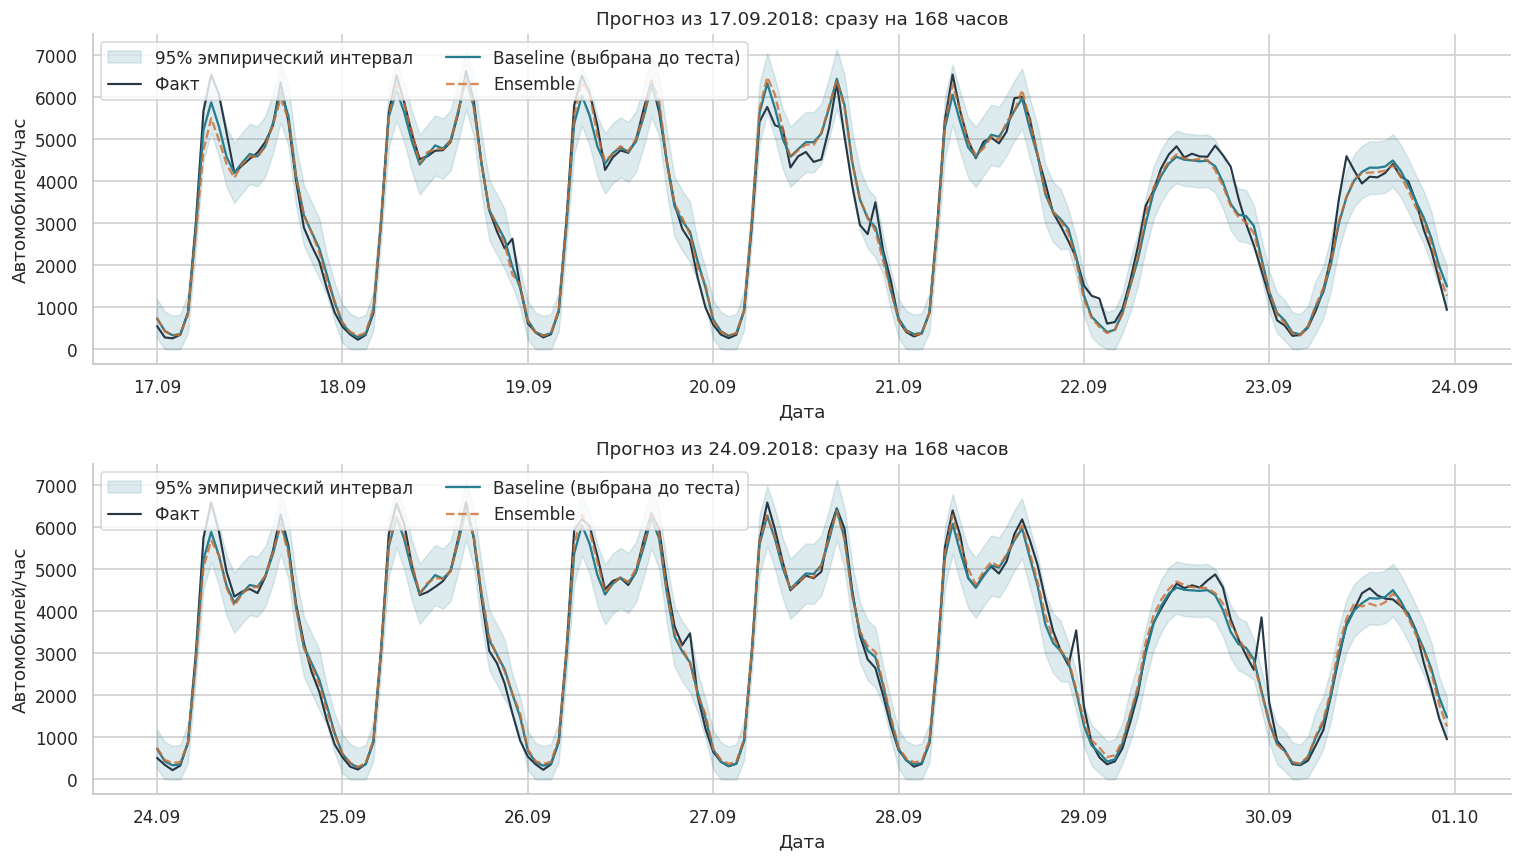

In [16]:
test_metrics, test_predictions, test_temperature = evaluate_origins(test_origins, label='Test')
test_summary_records = []
for name, part in test_predictions.groupby('model'):
    values = metric_values(part.actual, part.prediction)
    values['MASE_168'] = test_metrics.loc[test_metrics.model.eq(name), 'MASE_168'].mean()
    test_summary_records.append({'model': name, **values})
test_summary = pd.DataFrame(test_summary_records).set_index('model').sort_values('MAE')
test_summary['MAE_improvement_vs_baseline_%'] = 100 * (
    1 - test_summary.MAE / test_summary.loc['Baseline', 'MAE'])
test_summary['selected_on_validation'] = test_summary.index == SELECTED_MODEL
display(test_summary)
display(test_metrics.pivot(index='origin', columns='model', values='MAE'))
test_summary.to_csv(OUT / 'test_metrics.csv', encoding='utf-8-sig')
test_predictions.to_csv(OUT / 'test_predictions_all_models.csv', index=False, encoding='utf-8-sig')
selected_test = add_intervals(test_predictions.loc[test_predictions.model.eq(SELECTED_MODEL)])
comparison_name = 'Ensemble' if SELECTED_MODEL == 'Baseline' else 'Baseline'
comparison_test = test_predictions.loc[test_predictions.model.eq(comparison_name)]
selected_scored = selected_test.dropna(subset=['actual']).copy()
selected_scored['covered'] = selected_scored.actual.between(selected_scored.lower_95, selected_scored.upper_95)
coverage = selected_scored.covered.mean()
mean_width = (selected_scored.upper_95 - selected_scored.lower_95).mean()
display(pd.Series({'Номинальное покрытие, %': 95.0, 'Покрытие на тесте, %': coverage * 100,
                   'Средняя ширина, автомобилей/час': mean_width,
                   'Наблюдавшихся часов из 336': len(selected_scored)}, name='Интервалы на тесте').to_frame())
selected_scored['group'] = interval_group(selected_scored.date_time)
display(selected_scored.groupby('group').agg(n=('covered','size'), coverage=('covered','mean')))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharey=True)
for ax, origin in zip(axes, test_origins):
    part = selected_test.loc[selected_test.origin.eq(origin)]
    comparison = comparison_test.loc[comparison_test.origin.eq(origin)]
    ax.fill_between(part.date_time, part.lower_95, part.upper_95, color='#287d8e', alpha=.15,
                    label='95% эмпирический интервал')
    ax.plot(part.date_time, part.actual, color='#263746', linewidth=1.4, label='Факт')
    ax.plot(part.date_time, part.prediction, color='#287d8e', label=f'{SELECTED_MODEL} (выбрана до теста)')
    ax.plot(comparison.date_time, comparison.prediction, color='#cc6b2c',
            linestyle='--', alpha=.8, label=comparison_name)
    ax.set(title=f'Прогноз из {origin:%d.%m.%Y}: сразу на 168 часов', ylabel='Автомобилей/час', xlabel='Дата')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.legend(loc='upper left', ncols=2)
fig.tight_layout()
savefig('09_test_forecasts.png')

,MAE,bias
horizon_day,,
1,213.98,38.12
2,148.55,-4.27
3,185.34,76.14
4,210.82,-106.48
5,174.30,105.79
6,264.06,177.83
7,195.31,-55.56


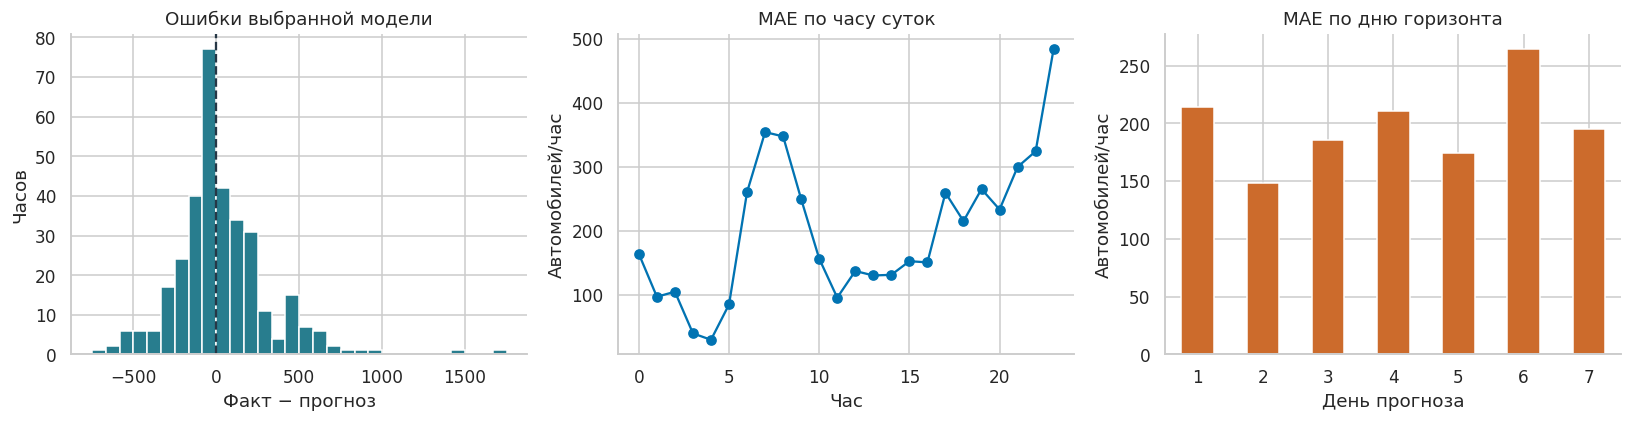

Выбрана по validation **Baseline**: тестовый MAE **198.9** против **198.9** у baseline; снижение MAE выбранной модели к baseline: **0.0%**. На самом тесте **Ensemble** достиг MAE **190.1**, что на **4.4%** лучше baseline по MAE. Таким образом, улучшение baseline на тесте получено, но на validation оно не подтвердилось; выбор модели после просмотра теста не меняем. Покрытие интервалов **95.5%**, средняя ширина **1221 автомобилей/час**.

In [17]:
selected_scored['error'] = selected_scored.actual - selected_scored.prediction
selected_scored['hour'] = selected_scored.date_time.dt.hour
selected_scored['horizon_day'] = (selected_scored.horizon - 1) // 24 + 1
error_by_day = selected_scored.groupby('horizon_day').error.agg(
    MAE=lambda values: values.abs().mean(), bias='mean')
display(error_by_day)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
selected_scored.error.hist(bins=30, ax=axes[0], color='#287d8e')
axes[0].axvline(0, color='#263746', linestyle='--')
axes[0].set(title='Ошибки выбранной модели', xlabel='Факт − прогноз', ylabel='Часов')
selected_scored.assign(abs_error=selected_scored.error.abs()).groupby('hour').abs_error.mean().plot(
    ax=axes[1], marker='o')
axes[1].set(title='MAE по часу суток', xlabel='Час', ylabel='Автомобилей/час')
error_by_day.MAE.plot.bar(ax=axes[2], rot=0, color='#cc6b2c')
axes[2].set(title='MAE по дню горизонта', xlabel='День прогноза', ylabel='Автомобилей/час')
fig.tight_layout()
savefig('10_error_diagnostics.png')

best_test_name = test_summary.index[0]
best_test_gain = test_summary.loc[best_test_name, 'MAE_improvement_vs_baseline_%']
improvement = test_summary.loc[SELECTED_MODEL, 'MAE_improvement_vs_baseline_%']
display(Markdown(
    f'Выбрана по validation **{SELECTED_MODEL}**: тестовый MAE '
    f'**{test_summary.loc[SELECTED_MODEL, "MAE"]:.1f}** против '
    f'**{test_summary.loc["Baseline", "MAE"]:.1f}** у baseline; '
    f'снижение MAE выбранной модели к baseline: **{improvement:.1f}%**. '
    f'На самом тесте **{best_test_name}** достиг MAE **{test_summary.iloc[0].MAE:.1f}**, '
    f'что на **{best_test_gain:.1f}%** лучше baseline по MAE. '
    'Таким образом, улучшение baseline на тесте получено, но на validation оно не подтвердилось; '
    'выбор модели после просмотра теста не меняем. '
    f'Покрытие интервалов **{coverage:.1%}**, средняя ширина **{mean_width:.0f} автомобилей/час**.'))

## 8. Прогноз следующей недели после конца датасета

После завершения независимой оценки тест становится обычной доступной историей.
Переобучаем **зафиксированную модель** на выбранном последнем окне, включая обе тестовые
недели. Строим 168 часов после последнего наблюдения. Это исторический прогноз на
**1–7 октября 2018 года**, а не прогноз от сегодняшней календарной даты.

Квантили интервалов оставляем прежними, оценёнными до теста: это позволяет сопоставить
будущие интервалы с уже проверенным покрытием. Будущие значения температуры при
необходимости вновь прогнозируются только по доступной истории. В этом горизонте
нет федеральных праздников; неизвестный будущий трафик не заполняется и не читается.

,date_time,prediction,lower_95,upper_95,model,is_holiday
0,2018-10-01 00:00:00,714.70,251.70,"1,177.70",Baseline,0
1,2018-10-01 01:00:00,421.20,0.00,884.20,Baseline,0
2,2018-10-01 02:00:00,324.50,0.00,787.50,Baseline,0
3,2018-10-01 03:00:00,351.00,0.00,814.00,Baseline,0
4,2018-10-01 04:00:00,865.20,402.20,"1,328.20",Baseline,0
5,2018-10-01 05:00:00,"2,822.50","2,359.50","3,285.50",Baseline,0
6,2018-10-01 06:00:00,"5,237.20","4,522.70","5,951.60",Baseline,0
7,2018-10-01 07:00:00,"5,923.10","5,208.60","6,637.50",Baseline,0
8,2018-10-01 08:00:00,"5,367.90","4,653.50","6,082.40",Baseline,0
9,2018-10-01 09:00:00,"4,627.30","3,912.80","5,341.80",Baseline,0


,Автомобилей за сутки (сумма прогноза),Среднее за час,Пиковый час
date_time,,,
2018-10-01,"81,288.20","3,387.00","6,090.50"
2018-10-02,"86,201.90","3,591.70","6,399.40"
2018-10-03,"85,491.30","3,562.10","6,187.50"
2018-10-04,"87,734.60","3,655.60","6,414.10"
2018-10-05,"88,609.70","3,692.10","6,109.00"
2018-10-06,"69,535.50","2,897.30","4,556.60"
2018-10-07,"61,694.70","2,570.60","4,496.80"


Интервалы отдельных часов нельзя просто сложить для получения 95%-интервала суточной суммы.


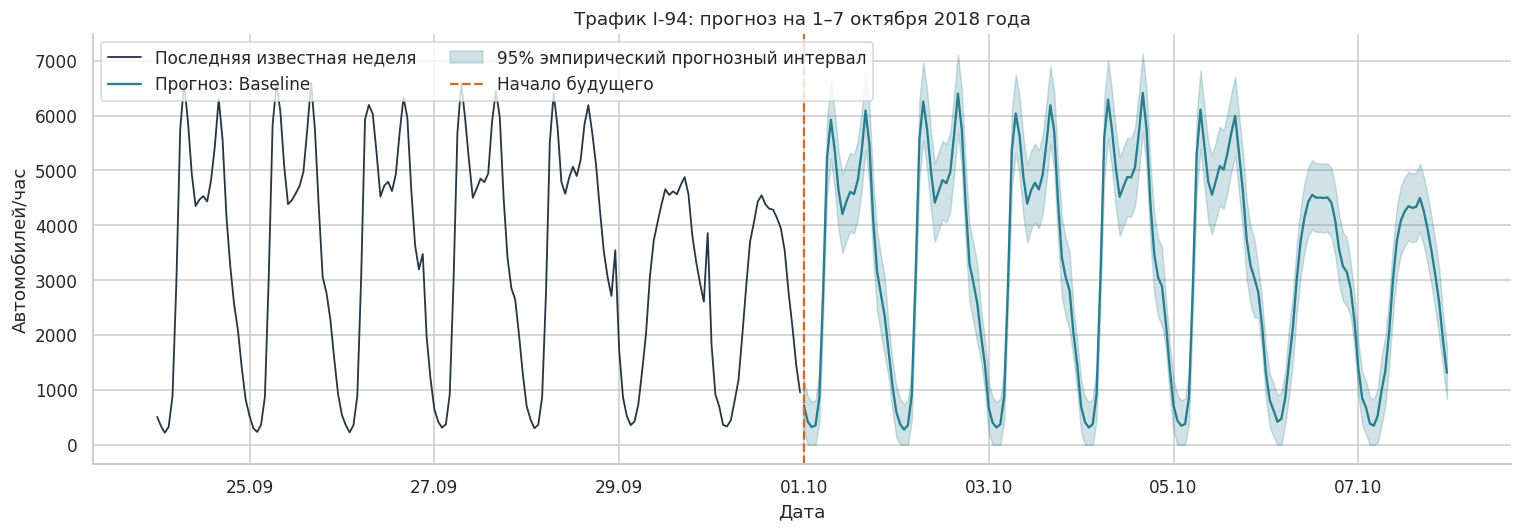

In [18]:
future_origin = grid.index.max() + pd.Timedelta(hours=1)
future_index = pd.date_range(future_origin, periods=HORIZON, freq='h', name='date_time')
final_history = history_before(future_origin, BEST_WEEKS)
future_predictions, future_temp = predict_models(final_history, future_index, [SELECTED_MODEL])
future_forecast = add_intervals(pd.DataFrame({
    'date_time': future_index, 'prediction': future_predictions[SELECTED_MODEL].to_numpy()}))
future_forecast['model'] = SELECTED_MODEL
future_forecast['is_holiday'] = calendar_features(future_index).is_holiday.to_numpy()
if SELECTED_MODEL == 'HistGB + temp':
    future_forecast['temp_forecast_c'] = future_temp
assert len(future_forecast) == 168
assert future_forecast.date_time.iloc[0] == grid.index.max() + pd.Timedelta(hours=1)
assert future_forecast.date_time.is_unique
assert future_forecast[['prediction','lower_95','upper_95']].notna().all().all()
assert (future_forecast.lower_95 >= 0).all()
future_forecast.to_csv(OUT / 'forecast_next_week.csv', index=False, encoding='utf-8-sig', float_format='%.3f')
display(future_forecast.head(12).round(1))
daily_forecast = future_forecast.set_index('date_time').prediction.resample('D').agg(['sum','mean','max'])
daily_forecast.columns = ['Автомобилей за сутки (сумма прогноза)', 'Среднее за час', 'Пиковый час']
display(daily_forecast.round(1))
print('Интервалы отдельных часов нельзя просто сложить для получения 95%-интервала суточной суммы.')

fig, ax = plt.subplots(figsize=(14, 5))
context = final_history.traffic_volume.tail(HORIZON)
ax.plot(context.index, context, label='Последняя известная неделя', color='#263746', linewidth=1.2)
ax.plot(future_index, future_forecast.prediction, label=f'Прогноз: {SELECTED_MODEL}', color='#287d8e')
ax.fill_between(future_index, future_forecast.lower_95, future_forecast.upper_95,
                color='#287d8e', alpha=.22, label='95% эмпирический прогнозный интервал')
ax.axvline(future_origin, color='#cc6b2c', linestyle='--', label='Начало будущего')
ax.set(title='Трафик I-94: прогноз на 1–7 октября 2018 года', ylabel='Автомобилей/час', xlabel='Дата')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.legend(loc='upper left', ncols=2)
fig.tight_layout()
savefig('11_next_week_forecast.png')

## 9. Ответы на вопросы и итоговые выводы

In [19]:
last_gap = gap_table.loc[gap_table.hours.idxmax()]
selected_row = test_summary.loc[SELECTED_MODEL]
temp_conclusion = ('помогла на validation' if temp_gain > 0 else 'не помогла на validation')
display(Markdown(f'''
1. **Что прогнозируем и на сколько шагов?** Почасовой автомобильный трафик I‑94,
   168 значений на неделю. Данные не дневные и не о пассажирах метро.
2. **Что исправлено в данных?** Из {len(raw):,} строк удалены {duplicate_rows:,} полных
   повторов выбранных полей; после объединения совпадающих часов осталось {len(hourly):,}
   уникальных меток. Часовая сетка содержит {len(grid):,} точку и {int(missing.sum()):,}
   изначально отсутствовавших часов. Числовые пропуски заполнены линейно внутри
   доступной истории, праздничные значения обработаны как календарные категории.
3. **Почему нельзя бездумно взять все годы?** Самый длинный провал —
   {int(last_gap.hours):,} часов ({last_gap.start:%d.%m.%Y}–{last_gap.end:%d.%m.%Y}).
   Его интерполяция не восстанавливает суточные колебания. Кроме того, уровень и профиль
   могут меняться. По validation выбрано **{BEST_WEEKS} недель**, что исключает этот разрыв.
   Это эмпирический выбор на данном периоде, не доказательство бесполезности старых лет вообще.
4. **Какие признаки нужны?** День недели и час дня, их взаимодействие (час недели),
   выходной/праздник, месяц и циклические признаки. Для регрессий — лаги 168/336/504/672,
   их среднее, отложенное скользящее среднее и индикаторы наблюдаемости лагов.
5. **Как устроен baseline?** Средние значения `groupby(['weekday','hour'])` по обучению.
   На финальном тесте MAE = **{test_summary.loc['Baseline','MAE']:.1f} автомобилей/час**.
6. **Какая модель выбрана и побит ли baseline?** По validation выбрана **{SELECTED_MODEL}**.
   На тесте MAE = **{selected_row.MAE:.1f}**, RMSE = **{selected_row.RMSE:.1f}**,
   WAPE = **{selected_row['WAPE_%']:.2f}%**, MASE(168) = **{selected_row.MASE_168:.3f}**.
   Для неё снижение MAE относительно baseline — **{improvement:.1f}%**.
   При этом **{best_test_name} побил baseline на тесте**: MAE **{test_summary.iloc[0].MAE:.1f}**,
   улучшение **{best_test_gain:.1f}%**. Поэтому задача поиска улучшения выполнена,
   но для будущей недели сохранён победитель validation. Перевыбрать модель по тесту
   означало бы использовать тест для настройки. Две недели не доказывают превосходство во всех сезонах.
7. **Помогла ли температура?** Прогнозная температура **{temp_conclusion}**:
   разность MAE без неё и с ней = **{temp_gain:+.1f} автомобилей/час**;
   MAE отдельного прогноза температуры = **{temp_mae:.2f} °C**.
   Реальная будущая температура никогда не использовалась в качестве признака.
8. **Где защита от утечки?** Хронологическое разбиение, заполнение только доступной истории,
   преобразования признаков только по train, недельные лаги не короче горизонта,
   метрики только на реальных наблюдениях, выбор до calibration/test. Вторая тестовая
   неделя использует первую только после её завершения.
9. **Что построено после теста?** После переобучения с включением тестовых дат получено
   **168 прогнозов с {future_index.min():%d.%m.%Y %H:%M} по {future_index.max():%d.%m.%Y %H:%M}**.
   Таблица с нижней и верхней границами сохранена в `outputs/forecast_next_week.csv`.
10. **Как понимать интервалы?** Это 95% номинальные почасовые прогнозные интервалы,
    откалиброванные на прошлых ошибках. На тесте покрытие **{coverage:.1%}** при средней
    ширине **{mean_width:.0f} автомобилей/час**. Зависимость ошибок, редкие праздники,
    изменение распределения и ошибки прогноза погоды ограничивают надёжность.
    Интервалы не дают 95% гарантии для всей траектории или суммы за неделю.
'''))


1. **Что прогнозируем и на сколько шагов?** Почасовой автомобильный трафик I‑94,
   168 значений на неделю. Данные не дневные и не о пассажирах метро.
2. **Что исправлено в данных?** Из 48,204 строк удалены 7,551 полных
   повторов выбранных полей; после объединения совпадающих часов осталось 40,575
   уникальных меток. Часовая сетка содержит 52,551 точку и 11,976
   изначально отсутствовавших часов. Числовые пропуски заполнены линейно внутри
   доступной истории, праздничные значения обработаны как календарные категории.
3. **Почему нельзя бездумно взять все годы?** Самый длинный провал —
   7,386 часов (08.08.2014–11.06.2015).
   Его интерполяция не восстанавливает суточные колебания. Кроме того, уровень и профиль
   могут меняться. По validation выбрано **13 недель**, что исключает этот разрыв.
   Это эмпирический выбор на данном периоде, не доказательство бесполезности старых лет вообще.
4. **Какие признаки нужны?** День недели и час дня, их взаимодействие (час недели),
   выходной/праздник, месяц и циклические признаки. Для регрессий — лаги 168/336/504/672,
   их среднее, отложенное скользящее среднее и индикаторы наблюдаемости лагов.
5. **Как устроен baseline?** Средние значения `groupby(['weekday','hour'])` по обучению.
   На финальном тесте MAE = **198.9 автомобилей/час**.
6. **Какая модель выбрана и побит ли baseline?** По validation выбрана **Baseline**.
   На тесте MAE = **198.9**, RMSE = **290.2**,
   WAPE = **5.90%**, MASE(168) = **0.749**.
   Для неё снижение MAE относительно baseline — **0.0%**.
   При этом **Ensemble побил baseline на тесте**: MAE **190.1**,
   улучшение **4.4%**. Поэтому задача поиска улучшения выполнена,
   но для будущей недели сохранён победитель validation. Перевыбрать модель по тесту
   означало бы использовать тест для настройки. Две недели не доказывают превосходство во всех сезонах.
7. **Помогла ли температура?** Прогнозная температура **не помогла на validation**:
   разность MAE без неё и с ней = **-11.8 автомобилей/час**;
   MAE отдельного прогноза температуры = **2.76 °C**.
   Реальная будущая температура никогда не использовалась в качестве признака.
8. **Где защита от утечки?** Хронологическое разбиение, заполнение только доступной истории,
   преобразования признаков только по train, недельные лаги не короче горизонта,
   метрики только на реальных наблюдениях, выбор до calibration/test. Вторая тестовая
   неделя использует первую только после её завершения.
9. **Что построено после теста?** После переобучения с включением тестовых дат получено
   **168 прогнозов с 01.10.2018 00:00 по 07.10.2018 23:00**.
   Таблица с нижней и верхней границами сохранена в `outputs/forecast_next_week.csv`.
10. **Как понимать интервалы?** Это 95% номинальные почасовые прогнозные интервалы,
    откалиброванные на прошлых ошибках. На тесте покрытие **95.5%** при средней
    ширине **1221 автомобилей/час**. Зависимость ошибок, редкие праздники,
    изменение распределения и ошибки прогноза погоды ограничивают надёжность.
    Интервалы не дают 95% гарантии для всей траектории или суммы за неделю.
